# Meta Methods applied to the ionosphere data set

In [2]:
import numpy as np
import pandas as pd
import sklearn as sk
from sklearn.model_selection import cross_val_score
#from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import (
    AdaBoostClassifier, 
    BaggingClassifier, 
    ExtraTreesClassifier,
    GradientBoostingClassifier, 
    RandomForestClassifier,
    VotingClassifier,
)


import  matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category = DeprecationWarning)  # To ignore warnings due to deprecated functions

%matplotlib inline

In [3]:
url = "http://archive.ics.uci.edu/ml/machine-learning-databases/ionosphere/ionosphere.data"
df = pd.read_csv(url,header = None)
df.head()

y = df[34].values
X = df.values[:,0:34]

## Voting scheme

In [4]:
cv = 50

clf1 = GaussianNB()

params = {
    "n_neighbors": list(range(1,30,2)), 
    "weights": ("distance", "uniform")
}
knc = KNeighborsClassifier()
clf = GridSearchCV(
    knc, 
    param_grid = params,
    cv = cv,
    n_jobs = -1
)
clf.fit(X, y)
print(f"Best Params fo Knn = {clf.best_params_}  -  Accuracy = {clf.best_score_}")

parval = clf.best_params_
clf2 = KNeighborsClassifier(
    n_neighbors = parval["n_neighbors"],
    weights = parval["weights"]
)

clf3 = DecisionTreeClassifier(criterion = "entropy")

for clf, label in zip([clf1, clf2, clf3], ['Naive Bayes','Knn (3)', 'Dec. Tree', ]):
    scores = cross_val_score(
        clf, 
        X, 
        y, 
        cv = cv, 
        scoring = "accuracy"
    )
    print("Accuracy: %0.3f [%s]" % (scores.mean(), label))  # TODO: update this part

Best Params fo Knn = {'n_neighbors': 1, 'weights': 'distance'}  -  Accuracy = 0.8635714285714284
Accuracy: 0.886 [Naive Bayes]
Accuracy: 0.864 [Knn (3)]
Accuracy: 0.895 [Dec. Tree]


In [5]:
eclf = VotingClassifier(
    estimators=[
        ("nb", clf1), 
        ("knn3", clf2), 
        ("dt", clf3)
    ],
    voting = "hard")
scores = cross_val_score(
    eclf, 
    X, 
    y, 
    cv = cv, 
    scoring = "accuracy"
)
print("Accuracy: %0.3f [%s]" % (scores.mean() , "Majority Voting"))  # TODO: update this part

Accuracy: 0.918 [Majority Voting]


In [6]:
eclf = VotingClassifier(
    estimators=[('nb', clf1), ('knn3', clf2), ('dt', clf3)],
    voting='soft', 
    weights=[2,1,2]
)
scores = cross_val_score(eclf, X, y, cv=cv, scoring='accuracy')
print("Accuracy: %0.3f [%s]" % (scores.mean(), "Weighted Voting"))

Accuracy: 0.920 [Weighted Voting]


## Bagging

In [7]:
lb=[]
for nest in [1,2,5,10,20,50,100,200]:
    scores = cross_val_score(
        BaggingClassifier(
            estimator = DecisionTreeClassifier(),
            n_estimators = nest
        ), 
        X, 
        y, 
        cv = cv, 
        scoring = "accuracy"
    )
    print("Accuracy: %0.3f [%s]" % (scores.mean(), nest))
    lb.append(scores.mean())

lb2=[]    
print()
for nest in [1,2,5,10,20,50,100,200]:
    scores = cross_val_score(
        BaggingClassifier(
            estimator = DecisionTreeClassifier(),
            n_estimators = nest,
            max_features = 0.35
        ), 
        X, 
        y, 
        cv = cv, 
        scoring = "accuracy"
    )
    print("Accuracy: %0.3f [%s]" % (scores.mean(), nest))
    lb2.append(scores.mean())

Accuracy: 0.866 [1]
Accuracy: 0.880 [2]
Accuracy: 0.920 [5]
Accuracy: 0.895 [10]
Accuracy: 0.912 [20]
Accuracy: 0.909 [50]
Accuracy: 0.923 [100]
Accuracy: 0.923 [200]

Accuracy: 0.857 [1]
Accuracy: 0.861 [2]
Accuracy: 0.912 [5]
Accuracy: 0.917 [10]
Accuracy: 0.934 [20]
Accuracy: 0.946 [50]
Accuracy: 0.929 [100]
Accuracy: 0.931 [200]


## Random Forest

In [13]:
lrf = []
for nest in [1,2,5,10,20,50,100,200]:
    scores = cross_val_score(
        RandomForestClassifier(n_estimators=nest), 
        X, 
        y, 
        cv=cv, 
        scoring='accuracy'
    )
    print("Accuracy: %0.3f [%s]" % (scores.mean(), nest))
    lrf.append(scores.mean())

Accuracy: 0.884 [1]
Accuracy: 0.858 [2]
Accuracy: 0.924 [5]
Accuracy: 0.943 [10]
Accuracy: 0.926 [20]
Accuracy: 0.940 [50]
Accuracy: 0.934 [100]
Accuracy: 0.934 [200]


In [8]:
lext = []
for nest in [1,2,5,10,20,50,100,200]:
    scores = cross_val_score(
        ExtraTreesClassifier(n_estimators = nest), 
        X, 
        y, 
        cv = cv, 
        scoring = "accuracy"
    )
    print("Accuracy: %0.3f [%s]" % (scores.mean(), nest))
    lext.append(scores.mean())

Accuracy: 0.872 [1]
Accuracy: 0.855 [2]
Accuracy: 0.938 [5]
Accuracy: 0.940 [10]
Accuracy: 0.954 [20]
Accuracy: 0.946 [50]
Accuracy: 0.943 [100]
Accuracy: 0.943 [200]


## Boosting

In [9]:
lboo = []
for nest in [1,2,5,10,20,50,100,200]:
    scores = cross_val_score(
        AdaBoostClassifier(n_estimators = nest), 
        X, 
        y, 
        cv = cv, 
        scoring = "accuracy"
    )
    print("Accuracy: %0.3f [%s]" % (scores.mean(), nest))
    lboo.append(scores.mean())

Accuracy: 0.824 [1]
Accuracy: 0.898 [2]
Accuracy: 0.909 [5]
Accuracy: 0.909 [10]
Accuracy: 0.920 [20]
Accuracy: 0.934 [50]
Accuracy: 0.932 [100]
Accuracy: 0.938 [200]


In [10]:
lboodt = []
for nest in [1,2,5,10,20,50,100,200]:
    scores = cross_val_score(
        AdaBoostClassifier(
            DecisionTreeClassifier(max_depth = 5),
            n_estimators = nest
        ), 
        X,
        y, 
        cv = cv, 
        scoring = "accuracy"
    )
    print("Accuracy: %0.3f [%s]" % (scores.mean(), nest))
    lboodt.append(scores.mean())

Accuracy: 0.864 [1]
Accuracy: 0.866 [2]
Accuracy: 0.895 [5]
Accuracy: 0.915 [10]
Accuracy: 0.932 [20]
Accuracy: 0.923 [50]
Accuracy: 0.932 [100]
Accuracy: 0.935 [200]


In [11]:
lgbboo = []
for nest in [1,2,5,10,20,50,100,200]:
    scores = cross_val_score(
        GradientBoostingClassifier(n_estimators = nest), 
        X, 
        y, 
        cv = cv, 
        scoring = "accuracy"
    )
    print("Accuracy: %0.3f [%s]" % (scores.mean(), nest))
    lgbboo.append(scores.mean())

Accuracy: 0.641 [1]
Accuracy: 0.641 [2]
Accuracy: 0.858 [5]
Accuracy: 0.889 [10]
Accuracy: 0.926 [20]
Accuracy: 0.929 [50]
Accuracy: 0.935 [100]
Accuracy: 0.946 [200]


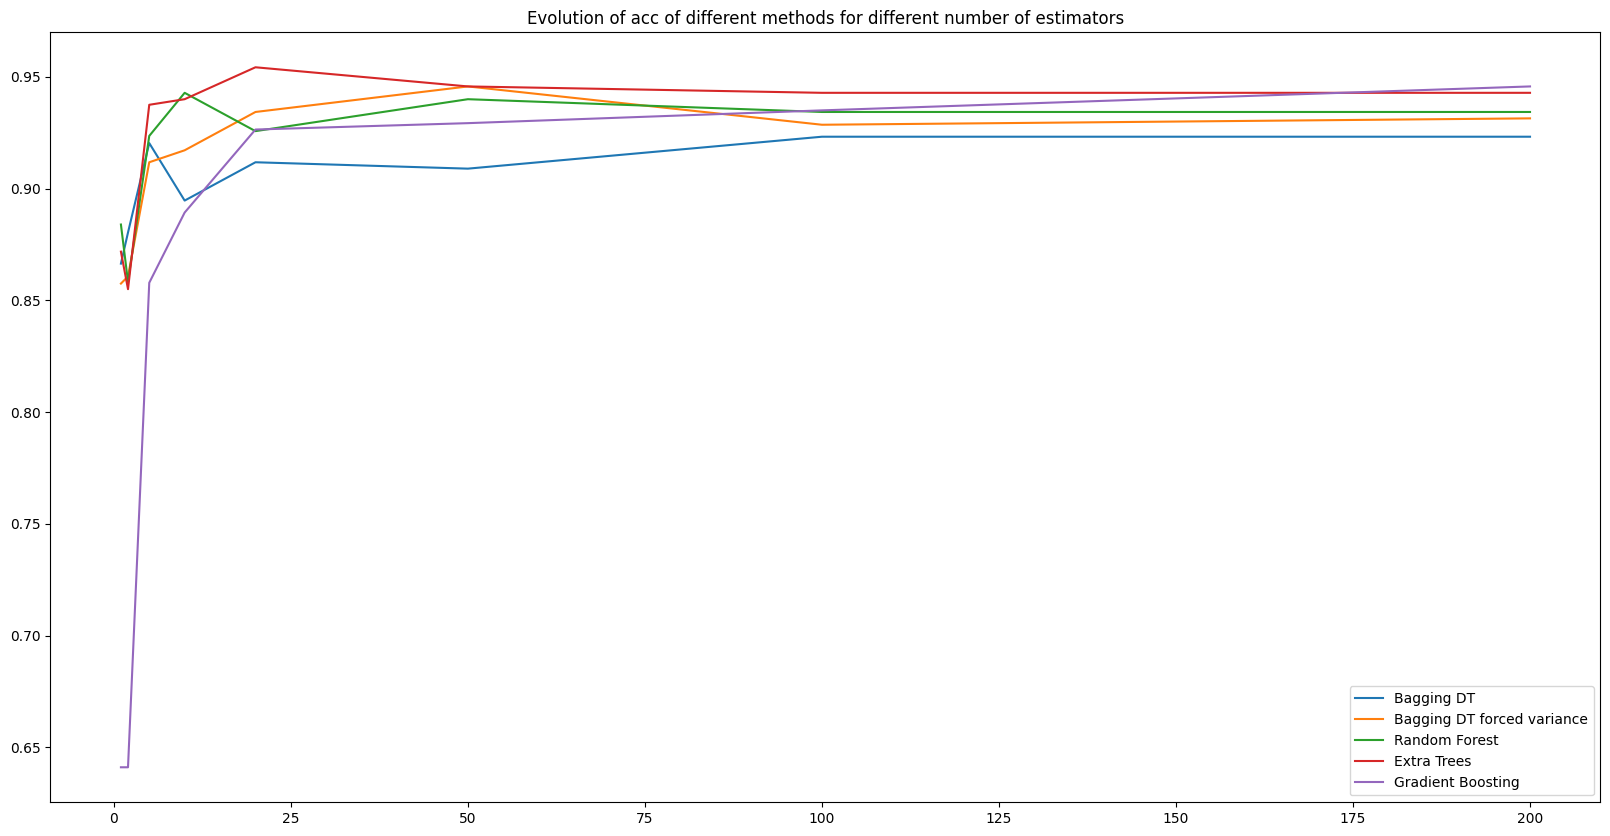

In [14]:
plt.figure(figsize = (20, 10))
plt.title("Evolution of acc of different methods for different number of estimators")
plt.plot([1,2,5,10,20,50,100,200],lb,label = "Bagging DT")
plt.plot([1,2,5,10,20,50,100,200],lb2,label = "Bagging DT forced variance")
plt.plot([1,2,5,10,20,50,100,200],lrf,label = "Random Forest")
plt.plot([1,2,5,10,20,50,100,200],lext,label = "Extra Trees")
plt.plot([1,2,5,10,20,50,100,200],lgbboo,label = "Gradient Boosting")
plt.legend(loc = "lower right")
plt.show()

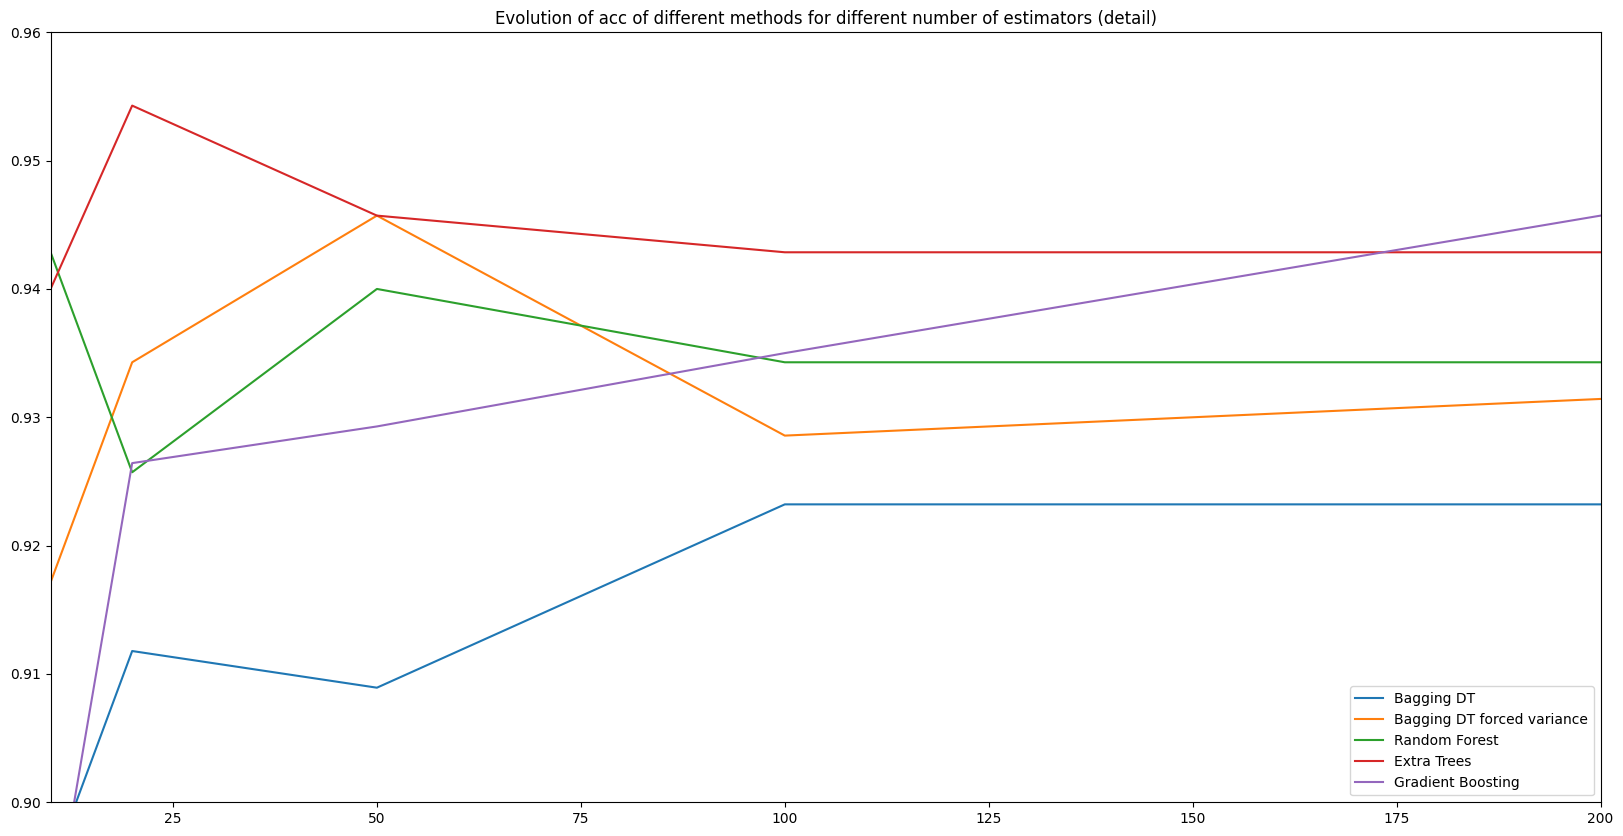

In [15]:
plt.figure(figsize = (20, 10))
plt.title("Evolution of acc of different methods for different number of estimators (detail)")
plt.plot([1,2,5,10,20,50,100,200],lb,label = "Bagging DT")
plt.plot([1,2,5,10,20,50,100,200],lb2,label = "Bagging DT forced variance")
plt.plot([1,2,5,10,20,50,100,200],lrf,label = "Random Forest")
plt.plot([1,2,5,10,20,50,100,200],lext,label = "Extra Trees")
plt.plot([1,2,5,10,20,50,100,200],lgbboo,label = "Gradient Boosting")
plt.legend(loc = "lower right")
plt.xlim(10,200)
plt.ylim(0.90,0.96)
plt.show()

## Feature Selection with Forests of trees

In [16]:
clf = RandomForestClassifier(n_estimators = 100)
clf = clf.fit(X, y)
print(clf.feature_importances_)

[0.02030358 0.         0.09901445 0.04372743 0.13513351 0.04318668
 0.09104561 0.03547363 0.01486047 0.01861553 0.00936819 0.0211685
 0.01286831 0.02820814 0.008873   0.02406265 0.00790731 0.02835351
 0.00668222 0.01313408 0.01222148 0.01728327 0.00927175 0.02458886
 0.00949351 0.01277482 0.09363709 0.0193962  0.02661264 0.00775725
 0.04953199 0.01670327 0.01895213 0.01978894]


In [17]:
from sklearn.feature_selection import SelectFromModel

model = SelectFromModel(clf, prefit = True, threshold = 0.05)
X_new = model.transform(X)
print(X_new.shape)

print(np.mean(cross_val_score(KNeighborsClassifier(), X = X, y = y, cv = cv, scoring = "accuracy")))
print(np.mean(cross_val_score(KNeighborsClassifier(), X = X_new, y = y, cv = cv, scoring = "accuracy")))

(351, 4)
0.837857142857143
0.9007142857142857


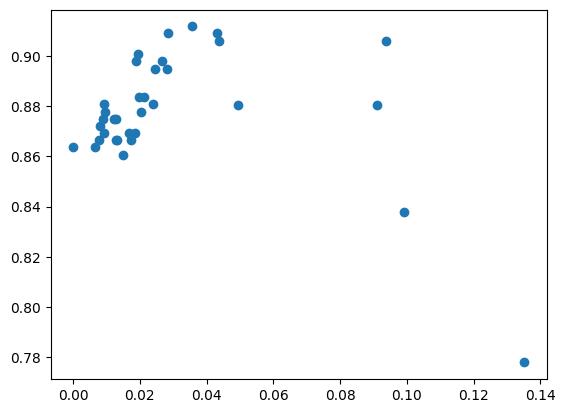

Best threshold: 0.03547363106448483


In [18]:
thresholds = clf.feature_importances_

l=[]
lparval=[]
for threshold in thresholds:
    model = SelectFromModel(
        clf, 
        prefit = True, 
        threshold = threshold
    )
    X_new = model.transform(X)
    params = {
        "n_neighbors": list(range(1,30,2)), 
        "weights": ("distance", "uniform")
    }
    
    knc = KNeighborsClassifier()
    clf2 = GridSearchCV(
        knc, 
        param_grid = params,
        cv = cv,
        n_jobs = -1
    )
    clf2.fit(X, y)
    parval = clf2.best_params_
    clf3 = KNeighborsClassifier(
        n_neighbors = parval["n_neighbors"],
        weights = parval["weights"]
    )
    acc = np.mean(cross_val_score(clf3, X = X_new, y = y, cv = cv, scoring = "accuracy"))
    l.append(acc)
    lparval.append(parval)
    
plt.scatter(thresholds,l)
plt.show()

print(f"Best threshold: {thresholds[np.argmax(l)]}")

In [20]:
parval = lparval[np.argmax(l)]
model = SelectFromModel(
    clf, 
    prefit = True, 
    threshold = thresholds[np.argmax(l)]
)
X_new = model.transform(X)
print(X_new.shape)


print("With FS: ", np.mean(cross_val_score(KNeighborsClassifier(n_neighbors=parval['n_neighbors'],weights=parval['weights']), X=X_new, y=y, cv=cv, scoring='accuracy')))

(351, 8)
With FS:  0.9117857142857142
